# 3. Train NeuralDMD on the visibilities

NeuralDMD represents the movie as a low-rank spatiotemporal decomposition,

$$ I(\mathbf{x}, t) \;=\; W_0(\mathbf{x})\, b_0 \;+\; 2\,\mathrm{Re}\!\left[ \sum_{k=1}^{r} W_k(\mathbf{x})\, b_k\, e^{\Omega_k \tau(t)} \right], \qquad \Omega_k = \alpha_k + i\,\theta_k, $$

with the real image guaranteed by the conjugate pairing (`r` counts complex modes directly).
The pieces, and how they differ from the original arXiv release:

- **spatial network** — a `ResidualMLP` (LayerNorm residual blocks) over positionally-encoded
  pixel coordinates outputs `[W0, Re W, Im W]`; modes are **gauge-fixed** to unit RMS
  (with stop-gradient), which pins down the W↔b scale freedom;
- **temporal networks** — two small latent-vector MLPs output the spectrum and amplitudes with
  constrained heads: `alpha = -sigmoid(·) ≤ 0` (no growing modes), `theta` bounded, `b` in
  polar form with a zero-initialized head (training starts from small dynamic amplitudes);
- **loss** — complex-visibility χ² through the per-frame forward operators, plus a negativity
  penalty on the image and L1 sparsity on both the modes and the amplitudes. The χ² is
  **reduced per real degree of freedom** (a complex visibility carries two: Re and Im), so
  `chi2_vis ≈ 1` means the model fits the data at the noise level. Amplitude and
  closure-phase χ² are computed **as diagnostics only** (the data here are phase-calibrated);
- **early stopping** — once the epoch-mean `chi2_vis` stays at or below `early_stop_chi2`
  (default 1.0) for a few consecutive epochs, training halts: past the noise level, further
  optimization fits noise;
- **initialization** — the spatial network starts from the Zernike disk template of
  notebook 02.

The ground-truth frames passed to the loader are used **only** for the reconstruction-error
diagnostic; gradients come exclusively from the visibility data.

⏱ Budget 10,000 epochs ≈ **30–45 min** on a laptop GPU (~0.2 s/epoch after the first compiled
epoch); early stopping usually ends the run before that. For a quick look, a few hundred
epochs already show the ring; the hot spot dynamics need a converged run.

In [1]:
import os
import numpy as np
import jax
import equinox as eqx

from neural_dmd import NeuralDMD, train_model
from dmd_data_loader import DMDDataLoader
from util_funcs import load_hdf5

obs_dir = "./data/EHT2017_cp/mring+hs_f0.04_resizedobs"
models_dir = "./models"
plots_dir = "./plots"
fov = np.pi

# model
r = 10
num_frequencies = 2

# training
num_epochs = 10_000
batch_size = 15       # frames per batch
time_fraction = 0.6   # fraction of frames sampled per epoch
lr = 3e-4

use_template = True        # start from the notebook-02 disk template
continue_training = False  # resume from a previous training checkpoint

In [2]:
frames, times = load_hdf5(obs_dir, "gt_video_resized.hdf5")
frame_max, frame_min = frames.max(), frames.min()
times = (times - times.min()) / (times.max() - times.min())  # normalize to [0, 1]

train_loader = DMDDataLoader(
    frames, batch_size=batch_size, epochs=num_epochs, data_dir=obs_dir,
    times=times, fov_x=fov, fov_y=fov, time_fraction=time_fraction,
)

[DMDDataLoader] dataset has 410 observed frames; trimming movie from 411 frames to match


In [3]:
key = jax.random.PRNGKey(42)
model = NeuralDMD(r, key=key, num_frequencies=num_frequencies)

if use_template:
    model = eqx.tree_deserialise_leaves(
        os.path.join(models_dir, f"disk_template_r{r}_f{num_frequencies}.eqx"), model)
if continue_training:
    model = eqx.tree_deserialise_leaves(
        os.path.join(models_dir, f"trained_model_r{r}_f{num_frequencies}.eqx"), model)

In [4]:
model, history = train_model(
    model, train_loader, num_epochs, key,
    models_dir=models_dir, plots_dir=plots_dir,
    frame_max=frame_max, frame_min=frame_min,
    initial_lr=lr, print_every=100, plot_every=500,
    early_stop_chi2=1.0,   # stop at the noise level (None to disable)
    early_stop_epochs=3,   # ... after this many consecutive epochs there
)

  1%|          | 100/10000 [00:24<19:23,  8.51it/s, chi2_cp=2.237, chi2_vis=3.652, loss=4.9872]        

Epoch 100/10000  loss=4.98723  chi2_vis=3.652  chi2_amp=3.654  chi2_cp=2.237  rec=22.0  lr=3.00e-04


  2%|▏         | 200/10000 [00:36<16:55,  9.65it/s, chi2_cp=2.063, chi2_vis=2.144, loss=3.5877]

Epoch 200/10000  loss=3.58774  chi2_vis=2.144  chi2_amp=1.950  chi2_cp=2.063  rec=18.4  lr=3.00e-04


  3%|▎         | 300/10000 [00:48<16:57,  9.54it/s, chi2_cp=1.846, chi2_vis=2.139, loss=3.5691]  

...

Epoch 900/10000  loss=2.72566  chi2_vis=1.317  chi2_amp=1.687  chi2_cp=1.656  rec=17.1  lr=3.00e-04


  9%|▉         | 934/10000 [02:02<19:31,  7.74it/s, chi2_cp=1.588, chi2_vis=0.943, loss=2.2780]

Early stop at epoch 934: chi2_vis = 0.943 <= 1.0 for 3 consecutive epochs (noise level reached; continuing would fit noise).


  9%|▉         | 934/10000 [02:02<19:53,  7.60it/s, chi2_cp=1.588, chi2_vis=0.943, loss=2.2780]

Best checkpoint saved to ./models/trained_model_r10_f2.eqx


## Training curves

`chi2_vis` is the data-space goodness of fit, reduced per degree of freedom: **1.0 is the
noise level**, and training early-stops there. On this dataset the *ground truth itself*
scores ≈ 0.6 (see `diagnostics.json`) because σ includes the 4% systematic budget — so the
default threshold is conservative; lower `early_stop_chi2` toward that value for a tighter
fit. The reconstruction error (`rec`) is the image-space diagnostic the loss never sees.

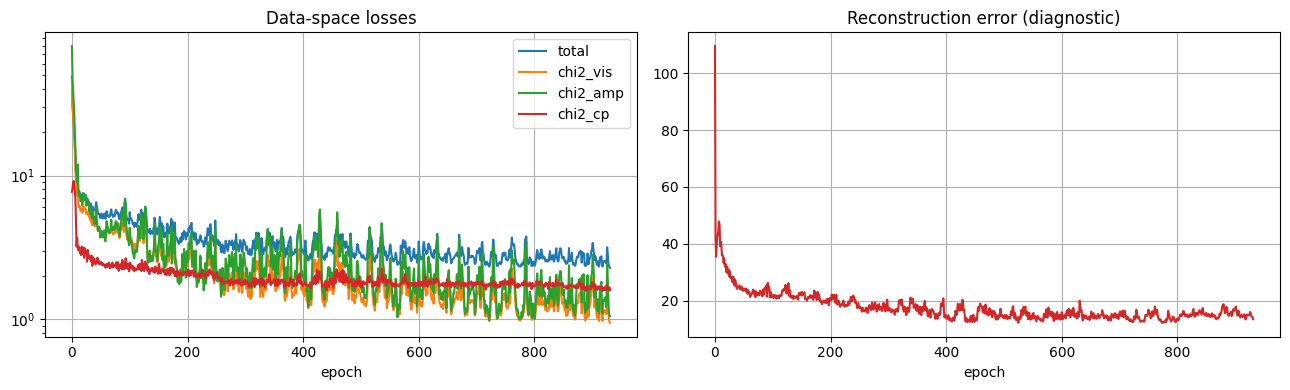

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for k in ["total", "chi2_vis", "chi2_amp", "chi2_cp"]:
    axes[0].plot(history[k][2:], label=k)
axes[0].set_xlabel("epoch"); axes[0].set_yscale("log"); axes[0].legend(); axes[0].grid(True)
axes[0].set_title("Data-space losses")

axes[1].plot(history["rec"][2:], color="C3")
axes[1].set_xlabel("epoch"); axes[1].set_title("Reconstruction error (diagnostic)"); axes[1].grid(True)
plt.tight_layout(); plt.show()

**Next:** [`04_evaluate.ipynb`](04_evaluate.ipynb) — modes, spectrum, reconstruction, and χ².